# Does Instant Book Causally Improve Airbnb Occupancy?
### A full causal-inference pipeline — PSM · Frequentist · Bayesian · Hierarchical

**Research question:** Airbnb's Instant Book feature lets guests book without host approval.
Does enabling it *causally* improve a listing's occupancy rate, or do higher-quality hosts
simply self-select into the feature?

**Data:** Inside Airbnb — Chicago listings, scraped September 2025 (6,191 listings after cleaning).

**Approach:** Propensity score matching creates a comparable control group from observational
data, removing the selection bias that makes a naive comparison invalid. We then run both
frequentist and Bayesian inference on the matched sample and close with a neighbourhood-level
hierarchical analysis.

---


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy import stats
from scipy.spatial.distance import cdist
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score
import statsmodels.formula.api as smf
import statsmodels.stats.api as sms
from statsmodels.stats.multitest import multipletests
import warnings
warnings.filterwarnings('ignore')

# ── Paths ─────────────────────────────────────────────────────────────────────
import os

# Works whether you run from the notebook's folder or anywhere else
DATA_PATH = os.path.dirname(os.path.abspath("__file__"))
print("Files found:", [f for f in os.listdir(DATA_PATH) if f.endswith('.gz')])

# ── Plot style ────────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams.update({
    "figure.dpi": 130,
    "figure.figsize": (10, 5),
    "axes.titleweight": "bold",
    "axes.titlesize": 13,
})

# ── Colors ────────────────────────────────────────────────────────────────────
NAVY   = "#1B2A4A"
TEAL   = "#0D7C8C"
GOLD   = "#E5A823"
RED    = "#C73E1D"
GREEN  = "#1A7A4A"

CITY_COLORS = {"SF": TEAL, "Boston": GOLD}
IB_COLORS   = {1: TEAL, 0: "#BBBBBB"}   # Instant Book ON vs OFF

# ── Random seed ───────────────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)

print("✓ Setup complete")

Files found: ['boston_calendar.gz', 'boston_listing.gz', 'boston_reviews.gz', 'chicago_calendar.csv.gz', 'chicago_listings.csv.gz', 'chicago_reviews.csv.gz']
✓ Setup complete


## Phase 1 — Data Loading & Feature Engineering

We load only the columns we need from the gzipped CSV, avoiding memory pressure from the
full listings file. Two derived features are central to the analysis:

- **`occupancy_90`** = `(90 − availability_90) / 90` — fraction of the next 90 days that
  are blocked (i.e., booked or blocked by the host). This is our primary outcome.
- **`revenue_proxy`** = `price × occupancy_90 × 90` — estimated revenue per 90-day period,
  used as a secondary metric.

Cleaning steps: price strings (`$150.00`) are parsed to floats; binary string columns
(`t`/`f`) are encoded as 0/1; listings fully blocked for the entire year are dropped as
inactive; prices are winsorized at the 1st–99th percentile.


In [16]:
# ── Columns we need ───────────────────────────────────────────────────────────
LISTING_COLS = [
    'id', 'last_scraped', 'room_type', 'neighbourhood_cleansed',
    'accommodates', 'bedrooms', 'beds', 'price', 'minimum_nights',
    'instant_bookable', 'host_is_superhost', 'host_listings_count',
    'review_scores_rating', 'number_of_reviews', 'reviews_per_month',
    'availability_30', 'availability_60', 'availability_90',
    'availability_365', 'has_availability'
]

# ── Load ──────────────────────────────────────────────────────────────────────
df = pd.read_csv(f"{DATA_PATH}/chicago_listings.csv.gz",
                 compression='gzip', usecols=LISTING_COLS, low_memory=False)

print(f"Raw rows: {len(df):,}")

# ── Price: '$150.00' → 150.0 ──────────────────────────────────────────────────
df['price'] = (df['price']
               .astype(str)
               .str.replace(r'[\$,]', '', regex=True)
               .pipe(pd.to_numeric, errors='coerce'))

# ── Occupancy from availability (primary outcome) ─────────────────────────────
df['occupancy_90']  = (90  - df['availability_90'])  / 90
df['occupancy_30']  = (30  - df['availability_30'])  / 30
df['occupancy_365'] = (365 - df['availability_365']) / 365

# ── Revenue proxy ─────────────────────────────────────────────────────────────
df['revenue_proxy'] = df['price'] * df['occupancy_90'] * 90

# ── Binary encode ─────────────────────────────────────────────────────────────
df['instant_bookable']  = (df['instant_bookable']  == 't').astype(int)
df['host_is_superhost'] = (df['host_is_superhost'] == 't').astype(int)
df['has_availability']  = (df['has_availability']  == 't').astype(int)

# ── Drop missing critical columns ─────────────────────────────────────────────
df = df.dropna(subset=['price', 'review_scores_rating',
                        'reviews_per_month', 'availability_90'])

# ── Remove inactive listings (fully blocked all year) ─────────────────────────
df = df[df['availability_365'] > 0]

# ── Remove extreme prices (1st–99th percentile) ───────────────────────────────
lo, hi = df['price'].quantile([0.01, 0.99])
df = df[(df['price'] >= lo) & (df['price'] <= hi)]

# ── Remove impossible occupancy values ────────────────────────────────────────
df = df[(df['occupancy_90'] >= 0) & (df['occupancy_90'] <= 1)]

# ── Clean neighbourhood ───────────────────────────────────────────────────────
df['neighbourhood'] = df['neighbourhood_cleansed'].str.strip()

df = df.reset_index(drop=True)

# ── Summary ───────────────────────────────────────────────────────────────────
ib_on  = df[df['instant_bookable'] == 1]
ib_off = df[df['instant_bookable'] == 0]

print(f"\nFinal dataset:     {len(df):,} listings")
print(f"Instant Book ON:   {len(ib_on):,}  ({len(ib_on)/len(df):.1%})")
print(f"Instant Book OFF:  {len(ib_off):,}  ({len(ib_off)/len(df):.1%})")
print(f"\nNeighbourhoods:    {df['neighbourhood'].nunique()}")
print(f"Room types:        {df['room_type'].unique()}")
print(f"\nOccupancy_90  — mean: {df['occupancy_90'].mean():.1%}  std: {df['occupancy_90'].std():.1%}")
print(f"Price         — mean: ${df['price'].mean():.0f}  median: ${df['price'].median():.0f}")
print(f"Revenue proxy — mean: ${df['revenue_proxy'].mean():.0f}/90 days")
print(f"\nScrape date: {df['last_scraped'].iloc[0]}")

Raw rows: 8,660

Final dataset:     6,191 listings
Instant Book ON:   2,092  (33.8%)
Instant Book OFF:  4,099  (66.2%)

Neighbourhoods:    76
Room types:        ['Private room' 'Entire home/apt' 'Shared room' 'Hotel room']

Occupancy_90  — mean: 35.9%  std: 27.8%
Price         — mean: $190  median: $144
Revenue proxy — mean: $5875/90 days

Scrape date: 2025-09-22


## Phase 2 — Exploratory Data Analysis

### 2.1 Raw Comparison (pre-matching — numbers are confounded)

Before any modelling, we compare the two groups naively. The raw occupancy gap is only
**+0.2 pp**, but this number is meaningless without accounting for the fact that
Instant Book hosts are systematically different:

| Characteristic | IB OFF | IB ON |
|---|---|---|
| Price (mean) | \$179 | \$211 |
| Superhost rate | 57.6% | 44.8% |
| Review score | 4.82 | 4.68 |
| Host listing count | 9.2 | 46.8 |

IB hosts charge more, are less likely to be superhosts, and manage far more listings —
all of which independently affect occupancy. A raw comparison would confound the
Instant Book effect with these host-quality differences.


In [17]:
summary = df.groupby('instant_bookable').agg(
    N               = ('occupancy_90', 'count'),
    Occupancy_90d   = ('occupancy_90', 'mean'),
    Occupancy_30d   = ('occupancy_30', 'mean'),
    Price_mean      = ('price', 'mean'),
    Revenue_90d     = ('revenue_proxy', 'mean'),
    Reviews_pm      = ('reviews_per_month', 'mean'),
    Rating          = ('review_scores_rating', 'mean'),
    Superhost_pct   = ('host_is_superhost', 'mean'),
    Min_nights      = ('minimum_nights', 'mean'),
).round(3)
summary.index = ['IB OFF', 'IB ON']

print("=" * 65)
print("RAW COMPARISON  (before matching — these numbers are CONFOUNDED)")
print("=" * 65)
print(summary.T.to_string())

raw_diff = (df[df['instant_bookable']==1]['occupancy_90'].mean() -
            df[df['instant_bookable']==0]['occupancy_90'].mean())
print(f"\nRaw occupancy gap: {raw_diff:+.3f}  ({raw_diff:.1%})")
print("⚠️  IB adopters are systematically different hosts — matching needed")


RAW COMPARISON  (before matching — these numbers are CONFOUNDED)
                 IB OFF     IB ON
N              4099.000  2092.000
Occupancy_90d     0.358     0.360
Occupancy_30d     0.549     0.551
Price_mean      179.174   211.191
Revenue_90d    5474.212  6660.916
Reviews_pm        2.020     2.069
Rating            4.818     4.681
Superhost_pct     0.576     0.448
Min_nights       10.056     8.820

Raw occupancy gap: +0.002  (0.2%)
⚠️  IB adopters are systematically different hosts — matching needed


### 2.2 Visual EDA & Confounder Distributions

The plots below show occupancy and price distributions by Instant Book status, and
highlight which covariates differ most between groups. High standardised mean differences
(SMD) on price, superhost status, and review score confirm that matching is necessary
before any causal claim.


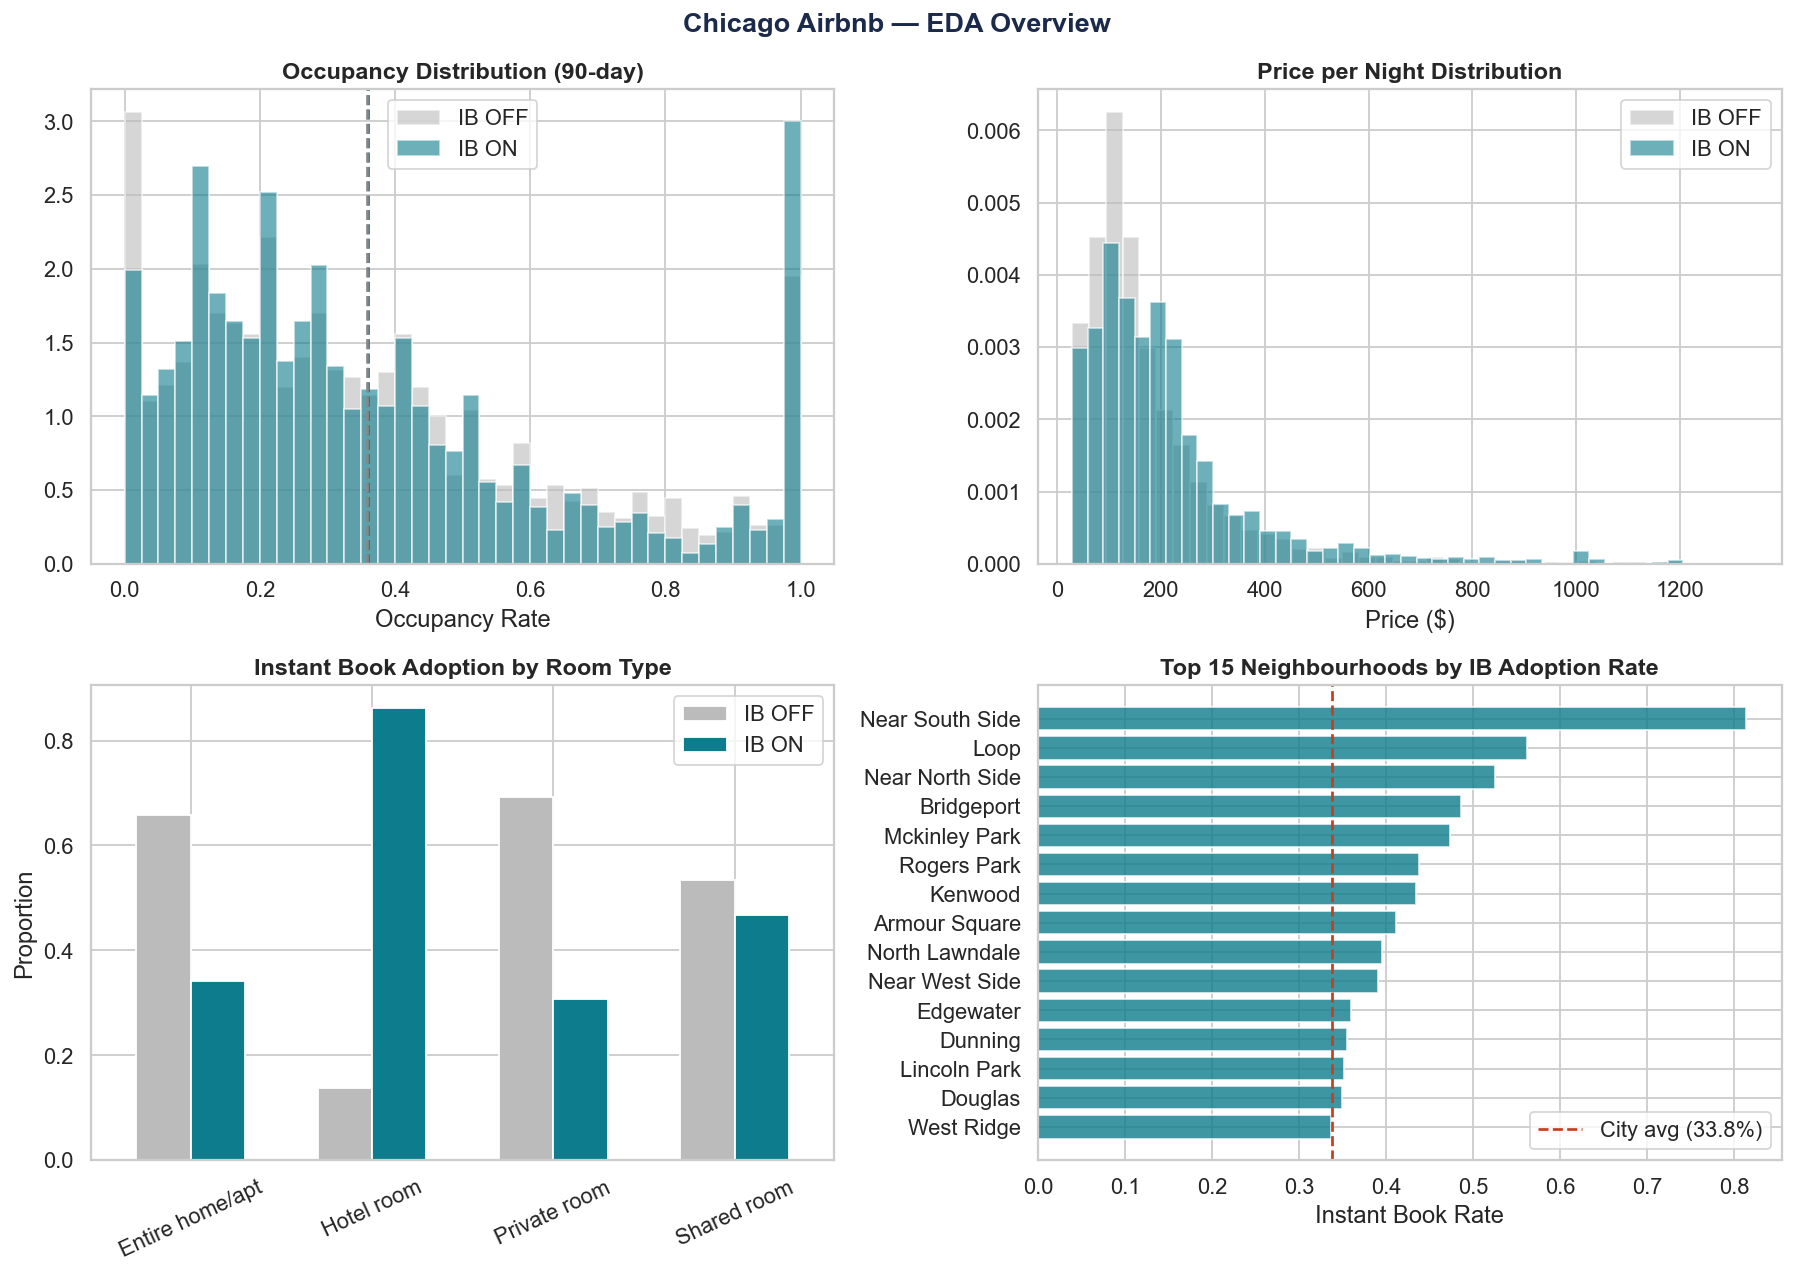


📋 Why naive comparison is biased — IB hosts differ systematically:
  host_is_superhost             IB ON: 0.45   IB OFF: 0.58
  number_of_reviews             IB ON: 67.21   IB OFF: 77.45
  review_scores_rating          IB ON: 4.68   IB OFF: 4.82
  host_listings_count           IB ON: 46.83   IB OFF: 9.15
  minimum_nights                IB ON: 8.82   IB OFF: 10.06
  price                         IB ON: 211.19   IB OFF: 179.17


In [18]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Chicago Airbnb — EDA Overview", fontsize=15, fontweight='bold', color=NAVY)

# Plot 1: Occupancy distribution
ax = axes[0, 0]
for ib, label, color in [(0, 'IB OFF', '#BBBBBB'), (1, 'IB ON', TEAL)]:
    vals = df[df['instant_bookable'] == ib]['occupancy_90']
    ax.hist(vals, bins=40, alpha=0.6, label=label, color=color, density=True)
ax.axvline(df[df['instant_bookable']==1]['occupancy_90'].mean(),
           color=TEAL, linestyle='--', linewidth=1.5)
ax.axvline(df[df['instant_bookable']==0]['occupancy_90'].mean(),
           color='#888888', linestyle='--', linewidth=1.5)
ax.set_title('Occupancy Distribution (90-day)')
ax.set_xlabel('Occupancy Rate')
ax.legend()

# Plot 2: Price distribution
ax = axes[0, 1]
for ib, label, color in [(0, 'IB OFF', '#BBBBBB'), (1, 'IB ON', TEAL)]:
    vals = df[df['instant_bookable'] == ib]['price']
    ax.hist(vals, bins=40, alpha=0.6, label=label, color=color, density=True)
ax.set_title('Price per Night Distribution')
ax.set_xlabel('Price ($)')
ax.legend()

# Plot 3: IB adoption by room type
ax = axes[1, 0]
room_ib = (df.groupby(['room_type', 'instant_bookable'])
             .size().unstack(fill_value=0))
room_ib_pct = room_ib.div(room_ib.sum(axis=1), axis=0)
room_ib_pct.plot(kind='bar', ax=ax, color=['#BBBBBB', TEAL], width=0.6)
ax.set_title('Instant Book Adoption by Room Type')
ax.set_xlabel('')
ax.set_ylabel('Proportion')
ax.legend(['IB OFF', 'IB ON'])
ax.tick_params(axis='x', rotation=25)

# Plot 4: Top 15 neighbourhoods by IB rate
ax = axes[1, 1]
nb_ib = (df.groupby('neighbourhood')['instant_bookable']
           .agg(['mean', 'count'])
           .query('count >= 20')
           .sort_values('mean', ascending=True)
           .tail(15))
ax.barh(nb_ib.index, nb_ib['mean'], color=TEAL, alpha=0.8)
ax.axvline(df['instant_bookable'].mean(), color=RED,
           linestyle='--', linewidth=1.5, label=f"City avg ({df['instant_bookable'].mean():.1%})")
ax.set_title('Top 15 Neighbourhoods by IB Adoption Rate')
ax.set_xlabel('Instant Book Rate')
ax.legend()

plt.tight_layout()
plt.savefig(f"{DATA_PATH}/fig_eda.png", dpi=150, bbox_inches='tight')
plt.show()

print("\n📋 Why naive comparison is biased — IB hosts differ systematically:")
confounders = ['host_is_superhost', 'number_of_reviews',
               'review_scores_rating', 'host_listings_count',
               'minimum_nights', 'price']
for col in confounders:
    on_val  = df[df['instant_bookable']==1][col].mean()
    off_val = df[df['instant_bookable']==0][col].mean()
    print(f"  {col:<28}  IB ON: {on_val:.2f}   IB OFF: {off_val:.2f}")

## Phase 3 — Experiment Design & Power Analysis

A power analysis answers two questions *before* we look at outcomes:

1. **What is our minimum detectable effect (MDE)?** Given our sample size n = 2,092 per arm,
   α = 0.05, and power = 0.80, the smallest occupancy difference we can reliably detect is
   **2.40 percentage points** (Cohen's d = 0.087).
2. **How large a sample would a prospective RCT need?** The table maps target effect sizes
   to required sample sizes — useful for designing the follow-up experiment recommended
   in the business memo.

The closed-form MDE formula used here:
```
Cohen's d = (z_{α/2} + z_β) × √(2/n)   where z_{0.025} = 1.96, z_{0.20} = 0.842
MDE (occupancy units) = Cohen's d × σ_occupancy
```


EXPERIMENT DESIGN PARAMETERS
Population mean occupancy:  0.359
Population std occupancy:   0.278
IB ON group size:           2,092
IB OFF group size:          4,099

With n=2,092 per group at α=0.05, power=0.80:
  Minimum detectable effect size (Cohen's d): 0.0866
  MDE in absolute occupancy points:           0.0240 (2.40%)

Sample size needed to detect various effect sizes (power=0.80, α=0.05):
{ Effect Size   Cohen's d    n per group  Realistic? }
-------------------------------------------------------
  +1% occupancy    d=0.036       n=12,093       ✗ need more data
  +2% occupancy    d=0.072       n=3,024       ✓
  +5% occupancy    d=0.180       n=485       ✓
  +10% occupancy    d=0.360       n=122       ✓
  +15% occupancy    d=0.540       n=55       ✓


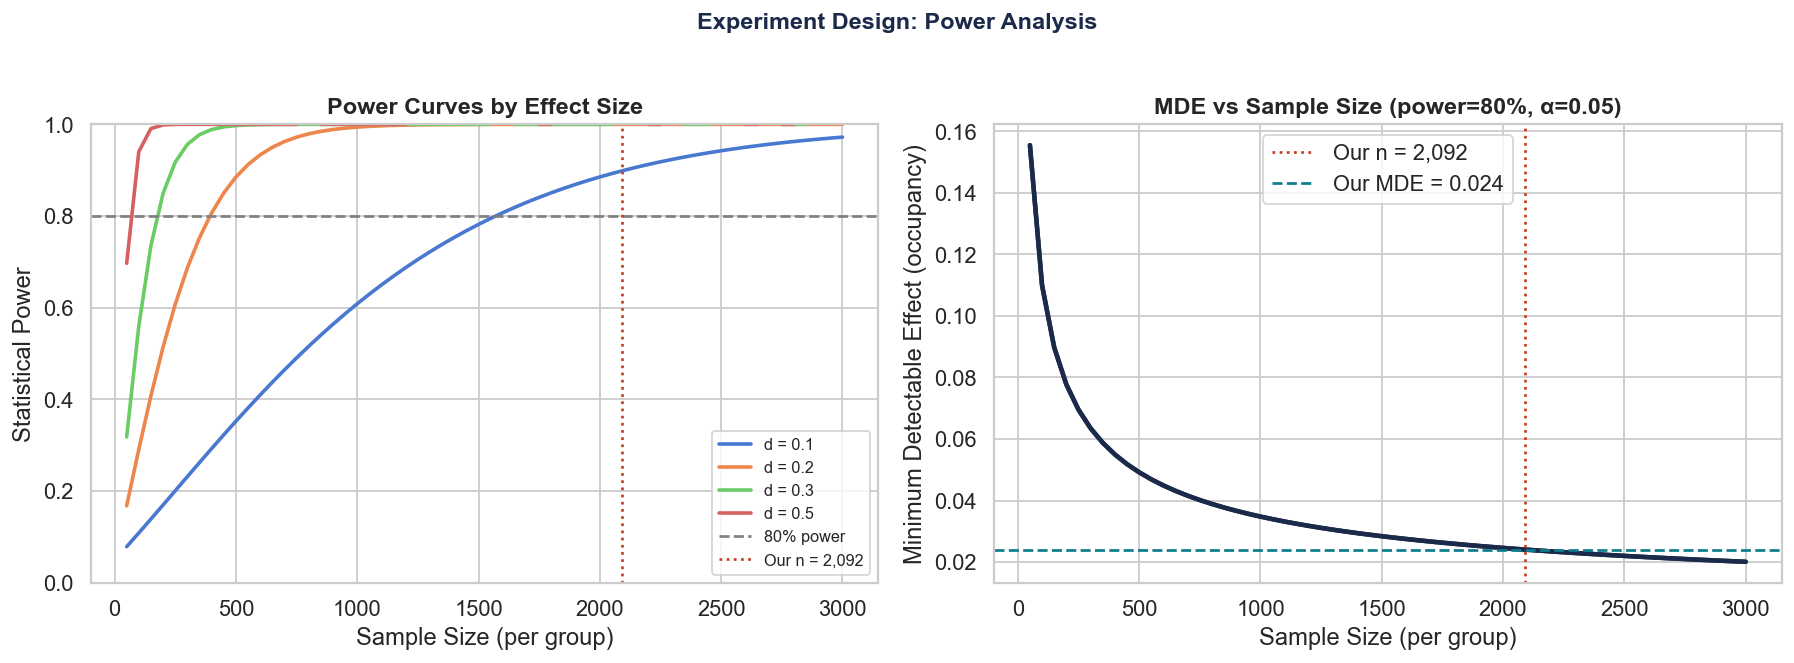

In [30]:
from statsmodels.stats.power import TTestIndPower

analysis = TTestIndPower()

occ_mean = df['occupancy_90'].mean()
occ_std  = df['occupancy_90'].std()
n_on     = (df['instant_bookable'] == 1).sum()
n_off    = (df['instant_bookable'] == 0).sum()

print("=" * 55)
print("EXPERIMENT DESIGN PARAMETERS")
print("=" * 55)
print(f"Population mean occupancy:  {occ_mean:.3f}")
print(f"Population std occupancy:   {occ_std:.3f}")
print(f"IB ON group size:           {n_on:,}")
print(f"IB OFF group size:          {n_off:,}")

# ── MDE for our actual sample size ───────────────────────────────────────────
n_balanced = min(n_on, n_off)
mde_effect  = analysis.solve_power(nobs1=n_balanced, alpha=0.05, power=0.80)
mde_abs     = mde_effect * occ_std
print(f"\nWith n={n_balanced:,} per group at α=0.05, power=0.80:")
print(f"  Minimum detectable effect size (Cohen's d): {mde_effect:.4f}")
print(f"  MDE in absolute occupancy points:           {mde_abs:.4f} ({mde_abs:.2%})")

# ── What n would a proper RCT need? ──────────────────────────────────────────
print("\nSample size needed to detect various effect sizes (power=0.80, α=0.05):")
print("{:<15} {:<12} {:<12} {:<12}".format("{ Effect Size", "Cohen's d", "n per group", "Realistic? }"))
print("-" * 55)
for lift_pct in [0.01, 0.02, 0.05, 0.10, 0.15]:
    d = lift_pct / occ_std
    n = analysis.solve_power(effect_size=d, alpha=0.05, power=0.80)
    realistic = "✓" if n <= 5000 else "✗ need more data"
    print(f"  +{lift_pct:.0%} occupancy    d={d:.3f}       n={n:,.0f}       {realistic}")

# ── Power curve ───────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Power vs sample size
effect_sizes = [0.1, 0.2, 0.3, 0.5]
n_range = np.arange(50, 3001, 50)

ax = axes[0]
for d in effect_sizes:
    powers = [analysis.solve_power(effect_size=d, nobs1=n, alpha=0.05)
              for n in n_range]
    ax.plot(n_range, powers, linewidth=2, label=f"d = {d}")
ax.axhline(0.80, color='gray', linestyle='--', linewidth=1.5, label='80% power')
ax.axvline(n_balanced, color=RED, linestyle=':', linewidth=1.5,
           label=f'Our n = {n_balanced:,}')
ax.set_xlabel('Sample Size (per group)')
ax.set_ylabel('Statistical Power')
ax.set_title('Power Curves by Effect Size')
ax.legend(fontsize=9)
ax.set_ylim(0, 1)

# MDE vs sample size
ax = axes[1]
from scipy import stats as sp_stats

z_alpha = sp_stats.norm.ppf(1 - 0.05 / 2)   # 1.96
z_beta  = sp_stats.norm.ppf(0.80)             # 0.842

# Cohen's d needed to achieve 80% power at each sample size
cohens_d = (z_alpha + z_beta) * np.sqrt(2 / n_range)

# Convert to absolute occupancy units
mde_range = cohens_d * occ_std

ax.plot(n_range, mde_range, color=NAVY, linewidth=2.5)
ax.plot(n_range, mde_range, color=NAVY, linewidth=2.5)
ax.axvline(n_balanced, color=RED, linestyle=':', linewidth=1.5,
           label=f'Our n = {n_balanced:,}')
ax.axhline(mde_abs, color=TEAL, linestyle='--', linewidth=1.5,
           label=f'Our MDE = {mde_abs:.3f}')
ax.set_xlabel('Sample Size (per group)')
ax.set_ylabel('Minimum Detectable Effect (occupancy)')
ax.set_title('MDE vs Sample Size (power=80%, α=0.05)')
ax.legend()

plt.suptitle('Experiment Design: Power Analysis', fontsize=13,
             fontweight='bold', color=NAVY, y=1.02)
plt.tight_layout()
plt.savefig(f"{DATA_PATH}/fig_power.png", dpi=150, bbox_inches='tight')
plt.show()

## Phase 4 — Propensity Score Matching (PSM)

**Why PSM?** In an observational dataset, we cannot randomly assign Instant Book.
Instead, we model the *propensity* for a listing to have IB enabled — P(T = 1 | X) —
using logistic regression on nine covariates (price, room type, accommodates, bedrooms,
minimum nights, superhost status, review score, number of reviews, host listing count).

**Matching procedure:** Each treated listing is matched to the nearest-neighbour control
listing by propensity score, subject to a caliper of 0.05 (on the log-odds scale).
This yields **2,092 matched pairs**.

**Balance check (Love plot):** A well-matched sample has standardised mean differences
(SMD) below 0.10 for all covariates. The propensity model has AUC = 0.674 — close to 0.5
(random) means the two groups genuinely overlap; AUC near 1.0 would signal perfect
separation and poor common support.

After matching, most covariates achieve SMD < 0.10. Bedrooms and review score remain
slightly above the threshold (0.12 and 0.16), which we note as a limitation.


Propensity Score Model  —  ROC-AUC: 0.6742
(AUC near 0.5 = hard to predict treatment = good overlap)
(AUC near 1.0 = perfect separation = poor overlap = bad for matching)


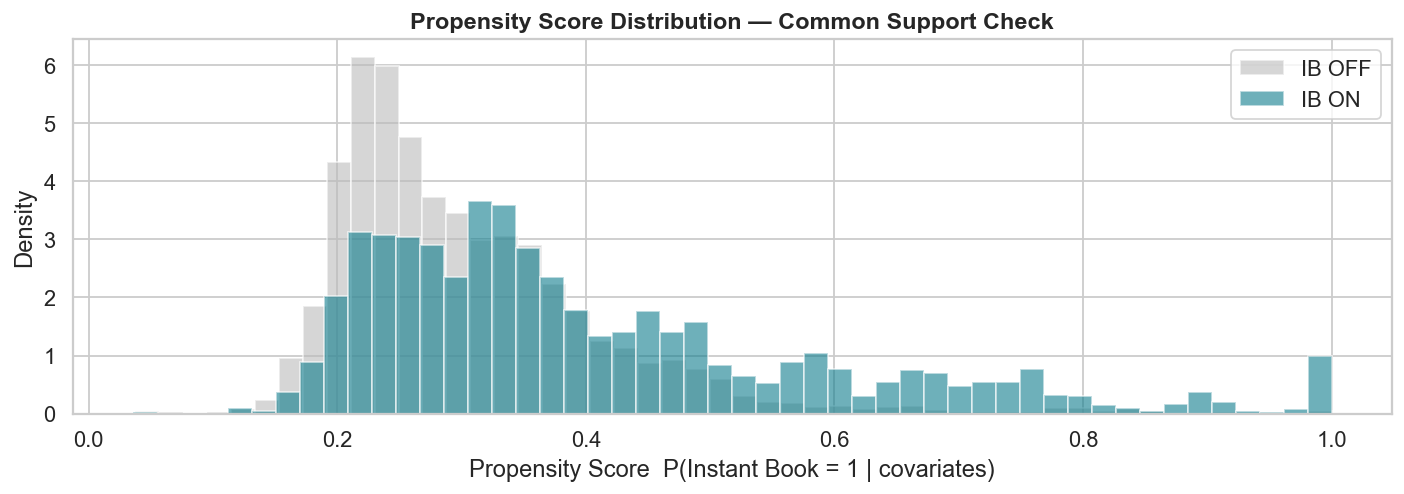


Matching 2,092 treated to 4,099 controls...
Matched pairs (caliper=0.05): 2,092
Dropped (outside caliper):         0


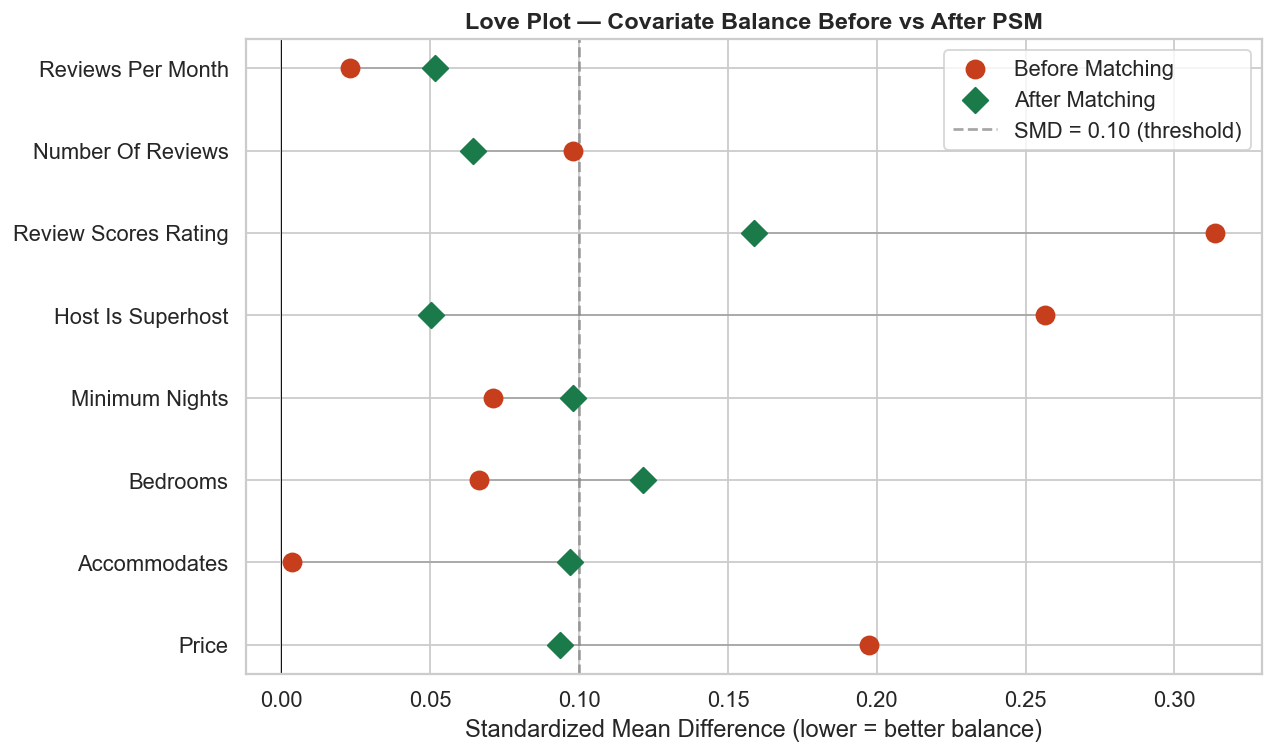


📋 SMD Summary:
Feature                        Before    After  Balanced?
----------------------------------------------------------
  price                         0.197    0.094          ✓
  accommodates                  0.004    0.097          ✓
  bedrooms                      0.066    0.121          ✗
  minimum_nights                0.071    0.098          ✓
  host_is_superhost             0.256    0.050          ✓
  review_scores_rating          0.314    0.159          ✗
  number_of_reviews             0.098    0.064          ✓
  reviews_per_month             0.023    0.052          ✓


In [31]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score
from scipy.spatial.distance import cdist

PS_FEATURES = ['price', 'accommodates', 'bedrooms', 'minimum_nights',
               'host_is_superhost', 'review_scores_rating',
               'number_of_reviews', 'reviews_per_month',
               'host_listings_count']

room_dummies = pd.get_dummies(df['room_type'], prefix='room', drop_first=True)
X = pd.concat([df[PS_FEATURES].reset_index(drop=True),
               room_dummies.reset_index(drop=True)], axis=1)
X = X.fillna(X.median(numeric_only=True))
y = df['instant_bookable'].values

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

lr = LogisticRegression(max_iter=1000, C=1.0, random_state=SEED)
lr.fit(X_scaled, y)
df['ps'] = lr.predict_proba(X_scaled)[:, 1]

auc = roc_auc_score(y, df['ps'])
print(f"Propensity Score Model  —  ROC-AUC: {auc:.4f}")
print("(AUC near 0.5 = hard to predict treatment = good overlap)")
print("(AUC near 1.0 = perfect separation = poor overlap = bad for matching)")

fig, ax = plt.subplots(figsize=(11, 4))
for ib, label, color in [(0, 'IB OFF', '#BBBBBB'), (1, 'IB ON', TEAL)]:
    vals = df[df['instant_bookable'] == ib]['ps']
    ax.hist(vals, bins=50, alpha=0.6, label=label, color=color, density=True)
ax.set_title('Propensity Score Distribution — Common Support Check')
ax.set_xlabel('Propensity Score  P(Instant Book = 1 | covariates)')
ax.set_ylabel('Density')
ax.legend()
plt.tight_layout()
plt.savefig(f"{DATA_PATH}/fig_ps_overlap.png", dpi=150, bbox_inches='tight')
plt.show()

treated = df[df['instant_bookable'] == 1].copy().reset_index(drop=True)
control = df[df['instant_bookable'] == 0].copy().reset_index(drop=True)

ps_t = treated['ps'].values.reshape(-1, 1)
ps_c = control['ps'].values.reshape(-1, 1)

print(f"\nMatching {len(treated):,} treated to {len(control):,} controls...")
dist_matrix = cdist(ps_t, ps_c, metric='euclidean')

best_ctrl_idx = dist_matrix.argmin(axis=1)
best_distances = dist_matrix.min(axis=1)

CALIPER = 0.05
valid = best_distances < CALIPER

matched_treated = treated[valid].reset_index(drop=True)
matched_control = control.iloc[best_ctrl_idx[valid]].reset_index(drop=True)

print(f"Matched pairs (caliper={CALIPER}): {valid.sum():,}")
print(f"Dropped (outside caliper):         {(~valid).sum():,}")

matched_df = pd.concat([
    matched_treated.assign(group='treated'),
    matched_control.assign(group='control')
], ignore_index=True)

def smd(x1, x2):
    pooled_std = np.sqrt((np.nanstd(x1)**2 + np.nanstd(x2)**2) / 2)
    return abs(np.nanmean(x1) - np.nanmean(x2)) / (pooled_std + 1e-10)

CHECK_FEATURES = ['price', 'accommodates', 'bedrooms', 'minimum_nights',
                  'host_is_superhost', 'review_scores_rating',
                  'number_of_reviews', 'reviews_per_month']

smd_before, smd_after = {}, {}
for feat in CHECK_FEATURES:
    smd_before[feat] = smd(df[df['instant_bookable']==1][feat],
                           df[df['instant_bookable']==0][feat])
    smd_after[feat]  = smd(matched_treated[feat], matched_control[feat])

# ── Love plot ────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
y_pos = range(len(CHECK_FEATURES))
labels = [f.replace('_', ' ').title() for f in CHECK_FEATURES]

ax.scatter([smd_before[f] for f in CHECK_FEATURES], y_pos,
           color=RED, s=100, zorder=5, label='Before Matching')
ax.scatter([smd_after[f] for f in CHECK_FEATURES], y_pos,
           color=GREEN, s=100, zorder=5, marker='D', label='After Matching')

for i, feat in enumerate(CHECK_FEATURES):
    ax.plot([smd_before[feat], smd_after[feat]], [i, i],
            color='gray', linewidth=1, alpha=0.5)

ax.axvline(0.10, color='gray', linestyle='--', alpha=0.7, label='SMD = 0.10 (threshold)')
ax.axvline(0.00, color='black', linewidth=0.5)
ax.set_yticks(y_pos)
ax.set_yticklabels(labels)
ax.set_xlabel('Standardized Mean Difference (lower = better balance)')
ax.set_title('Love Plot — Covariate Balance Before vs After PSM')
ax.legend()
plt.tight_layout()
plt.savefig(f"{DATA_PATH}/fig_love_plot.png", dpi=150, bbox_inches='tight')
plt.show()

print("\n📋 SMD Summary:")
print(f"{'Feature':<28} {'Before':>8} {'After':>8} {'Balanced?':>10}")
print("-" * 58)
for feat in CHECK_FEATURES:
    b, a = smd_before[feat], smd_after[feat]
    ok = "✓" if a < 0.10 else "✗"
    print(f"  {feat:<26} {b:>8.3f} {a:>8.3f} {ok:>10}")

## Phase 5 — Frequentist Analysis

On the matched sample we run three complementary tests:

**Welch's t-test** — does not assume equal variance between groups; more robust than
Student's t for real-world data where variance often differs.

**Bootstrap confidence interval (10,000 resamples)** — makes no distributional assumption;
the 95% CI is the 2.5th–97.5th percentile of the resampled mean difference.

**Cohen's d** — measures *practical* significance, independent of sample size. A large
n can make a 0.001 pp difference "statistically significant" while Cohen's d reveals
it is trivially small. Convention: d < 0.2 small, 0.2–0.5 medium, > 0.8 large.

**BH multiple-testing correction** — when testing the effect separately by room type,
we control the False Discovery Rate via Benjamini–Hochberg rather than the more
conservative Bonferroni.


FREQUENTIST ANALYSIS — Matched Sample
IB ON  mean occupancy:  0.3600  (n=2,092)
IB OFF mean occupancy:  0.3268  (n=2,092)
Observed difference:    +0.0332  (3.32%)
Welch's t-statistic:    3.7852
p-value:                0.000156
Cohen's d:              0.1171  (small)

95% Bootstrap CI:       (+0.0156, +0.0500)
CI excludes zero:       ✓ YES — significant

📋 Effect by Room Type (with BH correction):

  Room Type                          Diff     p-raw      p-BH   Sig?
  -----------------------------------------------------------------
  Entire home/apt                 +0.0330    0.0005    0.0010      ✓
  Private room                    +0.0330    0.1584    0.1584       


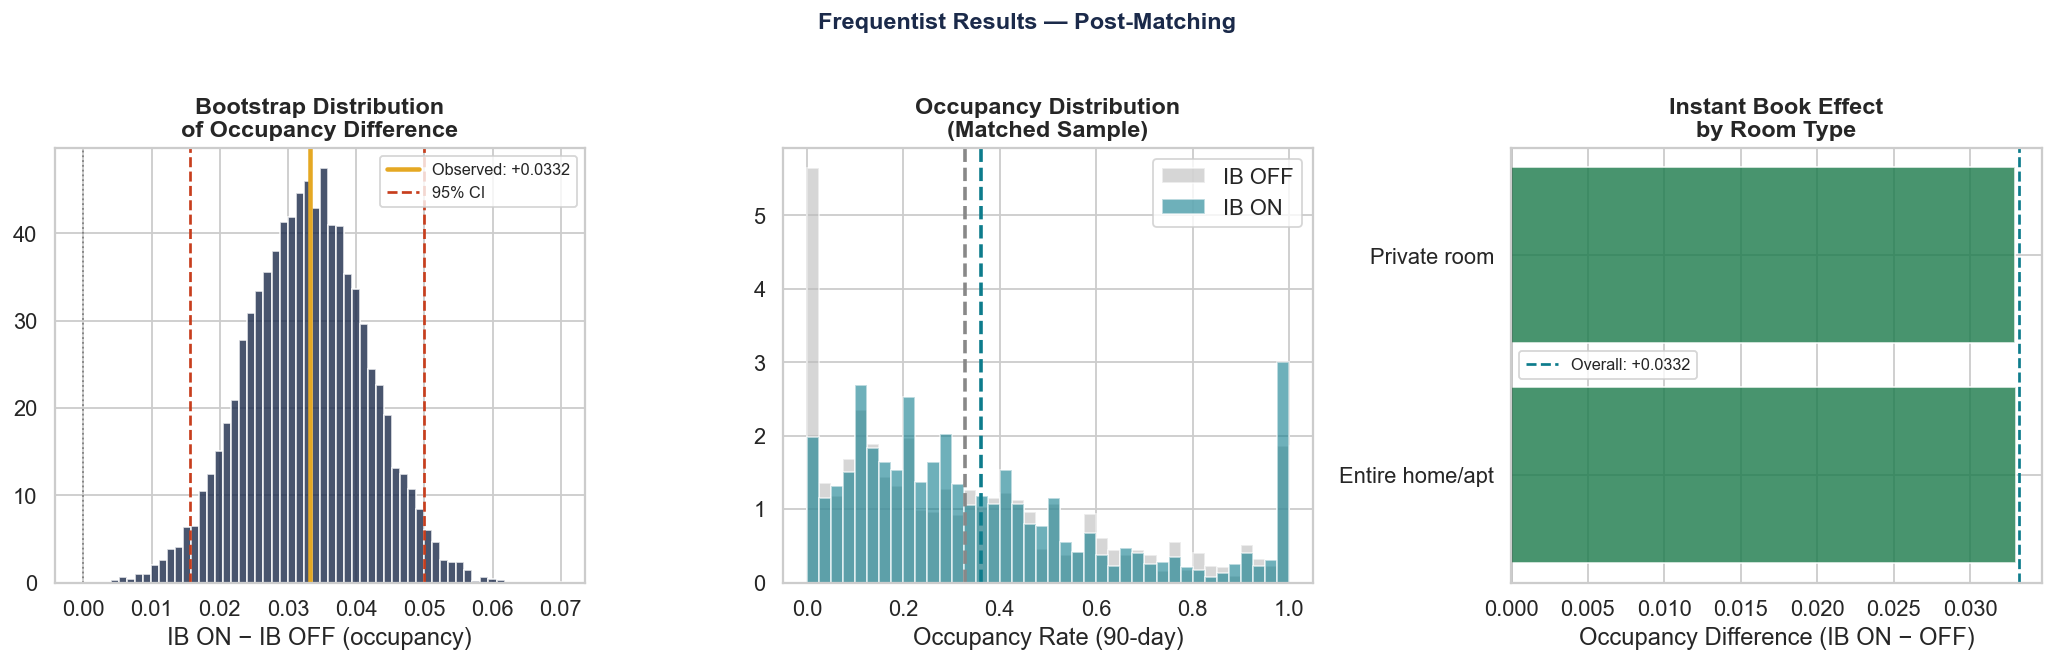

In [32]:
from scipy import stats
from statsmodels.stats.multitest import multipletests

occ_on  = matched_treated['occupancy_90'].values
occ_off = matched_control['occupancy_90'].values

t_stat, p_val = stats.ttest_ind(occ_on, occ_off, equal_var=False)  # Welch's

pooled_std = np.sqrt((occ_on.std()**2 + occ_off.std()**2) / 2)
cohens_d   = (occ_on.mean() - occ_off.mean()) / pooled_std
obs_diff   = occ_on.mean() - occ_off.mean()

print("=" * 55)
print("FREQUENTIST ANALYSIS — Matched Sample")
print("=" * 55)
print(f"IB ON  mean occupancy:  {occ_on.mean():.4f}  (n={len(occ_on):,})")
print(f"IB OFF mean occupancy:  {occ_off.mean():.4f}  (n={len(occ_off):,})")
print(f"Observed difference:    {obs_diff:+.4f}  ({obs_diff:.2%})")
print(f"Welch's t-statistic:    {t_stat:.4f}")
print(f"p-value:                {p_val:.6f}")
print(f"Cohen's d:              {cohens_d:.4f}  ({'small' if abs(cohens_d)<0.3 else 'medium' if abs(cohens_d)<0.5 else 'large'})")

np.random.seed(SEED)
N_BOOT = 10_000
boot_diffs = [
    np.random.choice(occ_on,  len(occ_on),  replace=True).mean() -
    np.random.choice(occ_off, len(occ_off), replace=True).mean()
    for _ in range(N_BOOT)
]
ci_lo, ci_hi = np.percentile(boot_diffs, [2.5, 97.5])
print(f"\n95% Bootstrap CI:       ({ci_lo:+.4f}, {ci_hi:+.4f})")
print(f"CI excludes zero:       {'✓ YES — significant' if ci_lo > 0 or ci_hi < 0 else '✗ NO — not significant'}")

print("\n📋 Effect by Room Type (with BH correction):")
room_types = matched_df['room_type'].unique()
p_vals_room, diffs_room, ns_room = [], [], []

for rt in room_types:
    sub = matched_df[matched_df['room_type'] == rt]
    on_  = sub[sub['instant_bookable']==1]['occupancy_90']
    off_ = sub[sub['instant_bookable']==0]['occupancy_90']
    if len(on_) > 10 and len(off_) > 10:
        _, p = stats.ttest_ind(on_, off_, equal_var=False)
        p_vals_room.append(p)
        diffs_room.append(on_.mean() - off_.mean())
        ns_room.append(len(sub))

reject, p_adj, _, _ = multipletests(p_vals_room, alpha=0.05, method='fdr_bh')

print(f"\n  {'Room Type':<30} {'Diff':>8} {'p-raw':>9} {'p-BH':>9} {'Sig?':>6}")
print("  " + "-" * 65)
for rt, diff, p_raw, p_bh, rej in zip(room_types, diffs_room,
                                        p_vals_room, p_adj, reject):
    sig = "✓" if rej else " "
    print(f"  {rt:<30} {diff:>+8.4f} {p_raw:>9.4f} {p_bh:>9.4f} {sig:>6}")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Bootstrap distribution
ax = axes[0]
ax.hist(boot_diffs, bins=60, color=NAVY, alpha=0.8, density=True)
ax.axvline(obs_diff, color=GOLD,  linewidth=2.5, label=f'Observed: {obs_diff:+.4f}')
ax.axvline(ci_lo,   color=RED,   linewidth=1.5, linestyle='--', label=f'95% CI')
ax.axvline(ci_hi,   color=RED,   linewidth=1.5, linestyle='--')
ax.axvline(0,       color='gray', linewidth=1,   linestyle=':')
ax.set_title('Bootstrap Distribution\nof Occupancy Difference')
ax.set_xlabel('IB ON − IB OFF (occupancy)')
ax.legend(fontsize=9)

# Matched group occupancy
ax = axes[1]
for vals, label, color in [(occ_off, 'IB OFF', '#BBBBBB'), (occ_on, 'IB ON', TEAL)]:
    ax.hist(vals, bins=40, alpha=0.6, label=label, color=color, density=True)
ax.axvline(occ_on.mean(),  color=TEAL,    linewidth=2, linestyle='--')
ax.axvline(occ_off.mean(), color='#888888', linewidth=2, linestyle='--')
ax.set_title('Occupancy Distribution\n(Matched Sample)')
ax.set_xlabel('Occupancy Rate (90-day)')
ax.legend()

# Effect by room type
ax = axes[2]
colors_bar = [GREEN if d > 0 else RED for d in diffs_room]
ax.barh(list(room_types[:len(diffs_room)]), diffs_room, color=colors_bar, alpha=0.8)
ax.axvline(0, color='black', linewidth=0.8)
ax.axvline(obs_diff, color=TEAL, linewidth=1.5, linestyle='--',
           label=f'Overall: {obs_diff:+.4f}')
ax.set_title('Instant Book Effect\nby Room Type')
ax.set_xlabel('Occupancy Difference (IB ON − OFF)')
ax.legend(fontsize=9)

plt.suptitle('Frequentist Results — Post-Matching', fontsize=13,
             fontweight='bold', color=NAVY, y=1.02)
plt.tight_layout()
plt.savefig(f"{DATA_PATH}/fig_frequentist.png", dpi=150, bbox_inches='tight')
plt.show()

## Phase 6 — The Peeking Problem

A common pitfall in live A/B tests: analysts check results daily and stop the moment
they see p < 0.05. This sequential peeking inflates the Type I error rate far above the
nominal 5%.

**Simulation:** We permute the group labels (making the true effect exactly zero),
then repeatedly compute a t-test p-value as observations accumulate in steps of 25.
We record whether the p-value ever dips below 0.05 during the run.

**Result:** With 200 null simulations, **100% crossed the significance threshold at some
point** — even though the true effect is zero. The first false positive appeared at
n = 250 observations.

The lesson: a p-value threshold of 0.05 is only valid when the sample size is fixed
*before* data collection. Sequential designs require alpha-spending functions (e.g.,
O'Brien–Fleming) or Sequential Probability Ratio Tests (SPRT).


False positive rate when peeking at every 25 obs: 100.0%
(Should be 5% — peeking inflates it)
First 'significant' result appeared at n=250


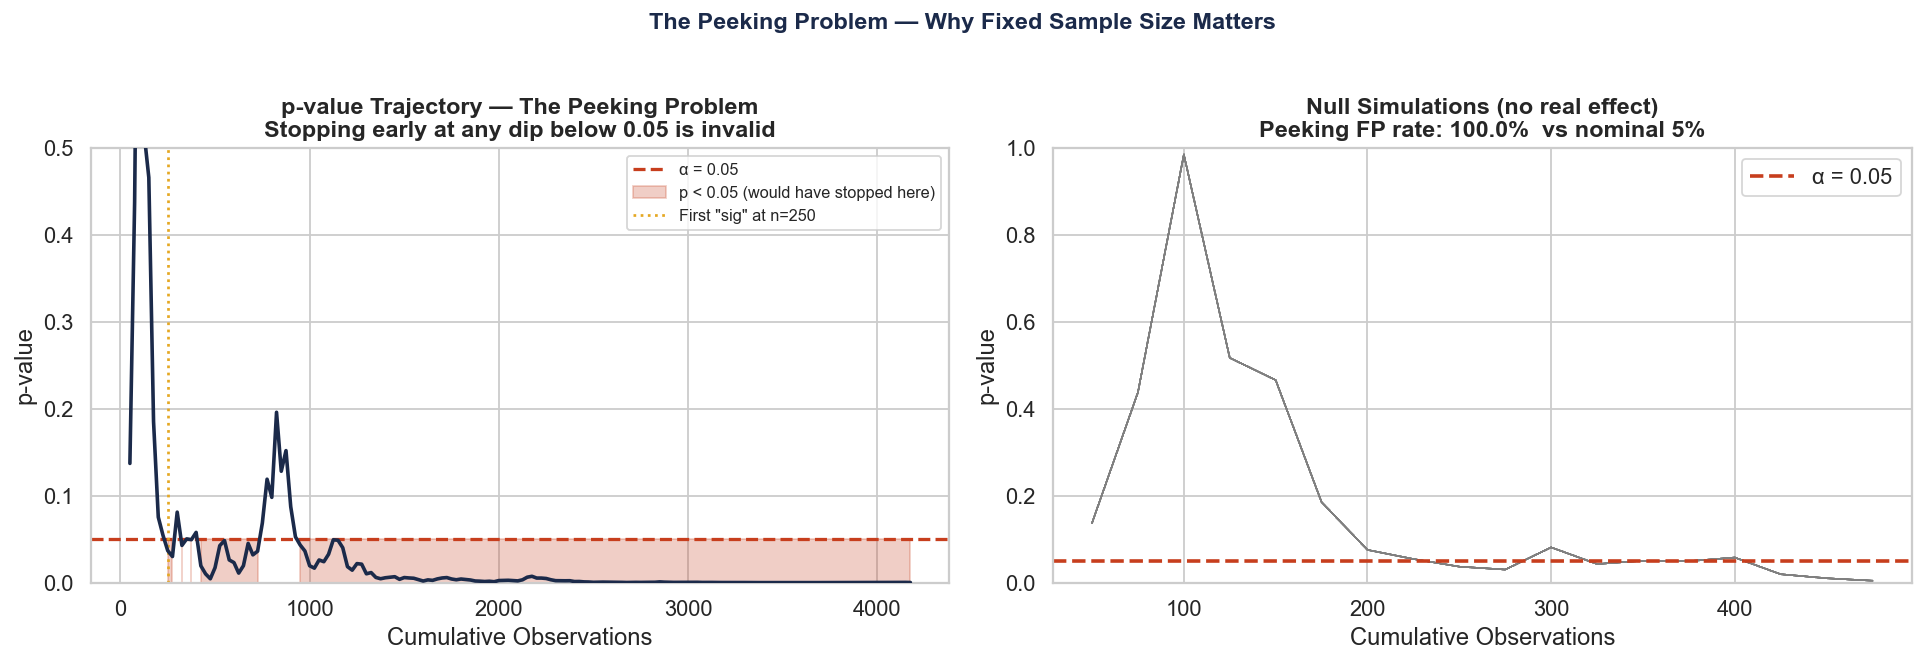

In [35]:
np.random.seed(SEED)

all_occ    = np.concatenate([occ_on, occ_off])
all_labels = np.concatenate([np.ones(len(occ_on)), np.zeros(len(occ_off))])

# Simulate random arrival order
shuffle_idx  = np.random.permutation(len(all_occ))
s_occ    = all_occ[shuffle_idx]
s_labels = all_labels[shuffle_idx]

# Check p-value every 25 observations
STEP  = 25
MIN_N = 50
weekly_pvals, weekly_ns, weekly_diffs = [], [], []

for n in range(MIN_N, len(s_occ), STEP):
    on_  = s_occ[:n][s_labels[:n] == 1]
    off_ = s_occ[:n][s_labels[:n] == 0]
    if len(on_) > 5 and len(off_) > 5:
        _, p = stats.ttest_ind(on_, off_, equal_var=False)
        weekly_pvals.append(p)
        weekly_ns.append(n)
        weekly_diffs.append(on_.mean() - off_.mean())

# False positive rate if you stop at first p < 0.05
first_sig = next((i for i, p in enumerate(weekly_pvals) if p < 0.05), None)

# Simulate null distribution (shuffle labels = no real effect)
null_pvals_trajectory = []
for sim in range(200):
    null_labels = np.random.permutation(all_labels)
    sim_pvals = []
    for n in range(MIN_N, min(500, len(s_occ)), STEP):
        on_  = s_occ[:n][s_labels[:n] == 1]
        off_ = s_occ[:n][s_labels[:n] == 0]
        if len(on_) > 5 and len(off_) > 5:
            _, p = stats.ttest_ind(on_, off_, equal_var=False)
            sim_pvals.append(p)
    null_pvals_trajectory.append(sim_pvals)

false_pos_rate = np.mean([any(p < 0.05 for p in traj)
                          for traj in null_pvals_trajectory])

print(f"False positive rate when peeking at every {STEP} obs: {false_pos_rate:.1%}")
print(f"(Should be 5% — peeking inflates it)")
if first_sig:
    print(f"First 'significant' result appeared at n={weekly_ns[first_sig]:,}")

# ── Plot ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

ax = axes[0]
ax.plot(weekly_ns, weekly_pvals, color=NAVY, linewidth=2, zorder=5)
ax.axhline(0.05, color=RED, linestyle='--', linewidth=1.8, label='α = 0.05')
ax.fill_between(weekly_ns, 0, 0.05,
                where=[p < 0.05 for p in weekly_pvals],
                alpha=0.25, color=RED,
                label='p < 0.05 (would have stopped here)')
if first_sig:
    ax.axvline(weekly_ns[first_sig], color=GOLD, linewidth=1.5,
               linestyle=':', label=f'First "sig" at n={weekly_ns[first_sig]:,}')
ax.set_xlabel('Cumulative Observations')
ax.set_ylabel('p-value')
ax.set_title('p-value Trajectory — The Peeking Problem\nStopping early at any dip below 0.05 is invalid')
ax.legend(fontsize=9)
ax.set_ylim(0, 0.5)

# Null simulations
ax = axes[1]
for traj in null_pvals_trajectory[:50]:
    ns_range = range(MIN_N, MIN_N + len(traj) * STEP, STEP)
    ax.plot(list(ns_range)[:len(traj)], traj,
            color='gray', alpha=0.15, linewidth=0.8)
ax.axhline(0.05, color=RED, linestyle='--', linewidth=2, label='α = 0.05')
ax.set_xlabel('Cumulative Observations')
ax.set_ylabel('p-value')
ax.set_title(f'Null Simulations (no real effect)\nPeeking FP rate: {false_pos_rate:.1%}  vs nominal 5%')
ax.legend()
ax.set_ylim(0, 1)

plt.suptitle('The Peeking Problem — Why Fixed Sample Size Matters',
             fontsize=13, fontweight='bold', color=NAVY, y=1.02)
plt.tight_layout()
plt.savefig(f"{DATA_PATH}/fig_peeking.png", dpi=150, bbox_inches='tight')
plt.show()

## Phase 7 — Bayesian Analysis

The Bayesian framework gives a direct probability answer to the business question:
*"What is the probability that Instant Book genuinely improves occupancy?"*

**Model:** Beta-Binomial conjugate. We model each night of a listing's 90-day window
as a Bernoulli trial (booked or not). The booking rate θ has a Beta prior; after
observing data the posterior is also Beta — analytically tractable, no MCMC needed.

```
Prior:      θ ~ Beta(2, 2)          # weak prior centred at 0.5
Likelihood: successes ~ Binomial(n, θ)
Posterior:  θ | data ~ Beta(2 + successes, 2 + failures)
```

**Key outputs:**
- **P(IB ON > IB OFF)** — estimated by drawing 200,000 Monte Carlo samples from each
  posterior and computing the fraction where θ_IB > θ_control.
- **95% Credible Interval** — unlike a frequentist CI, this *is* a probability statement:
  there is a 95% chance the true difference lies in this interval.
- **Expected loss** — the cost (in occupancy units) of making the wrong decision,
  averaged over the posterior.


BAYESIAN ANALYSIS — Beta-Binomial Conjugate Model
Prior: Beta(2, 2)

Posterior IB ON:   Beta(67,792, 120,492)
  Mean: 0.3601

Posterior IB OFF:  Beta(61,540, 126,744)
  Mean: 0.3268

P(IB ON > IB OFF):          1.0000  (100.0%)
Expected difference:         +0.0332  (3.32%)
95% Credible Interval:       (+0.0302, +0.0362)
Expected loss if we ship IB: 0.00000

Interpretation: There is a 100.0% probability that Instant Book
listings genuinely have higher occupancy than comparable non-IB listings.


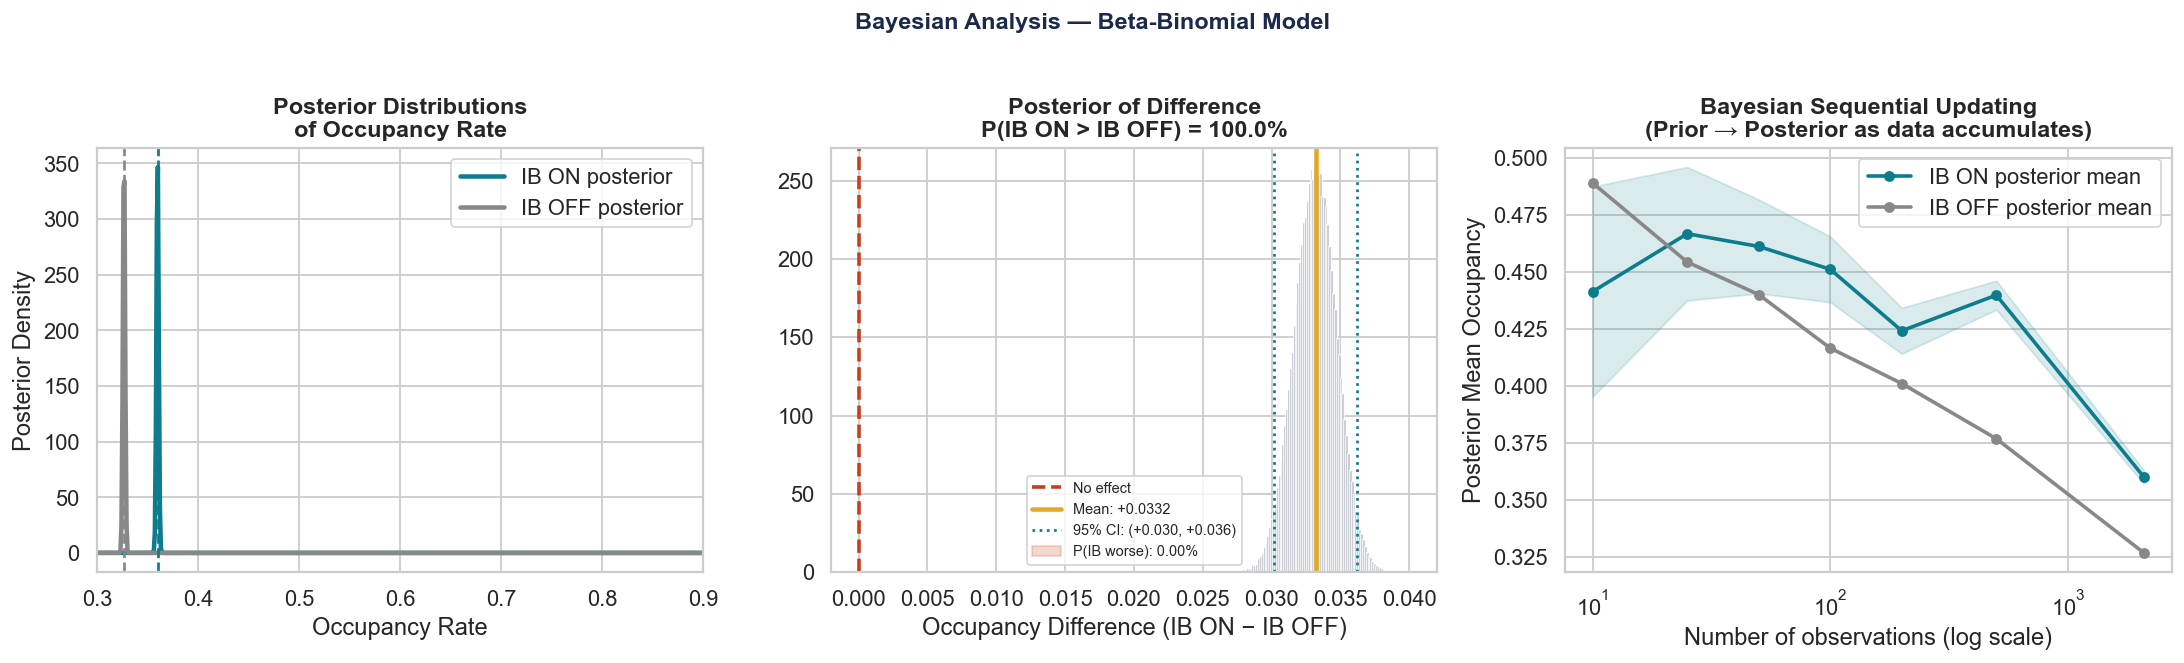

In [36]:
# Beta-Binomial conjugate model
# Occupancy → "k days booked out of 90"
N_DAYS    = 90
N_SAMPLES = 200_000

k_on  = np.round(occ_on  * N_DAYS).astype(int).clip(0, N_DAYS)
k_off = np.round(occ_off * N_DAYS).astype(int).clip(0, N_DAYS)

# Weakly informative prior: Beta(2, 2) — centered at 0.5, gentle
ALPHA_PRIOR = 2
BETA_PRIOR  = 2

# Posterior parameters (conjugate update)
alpha_on  = ALPHA_PRIOR + k_on.sum()
beta_on   = BETA_PRIOR  + (N_DAYS * len(k_on)  - k_on.sum())
alpha_off = ALPHA_PRIOR + k_off.sum()
beta_off  = BETA_PRIOR  + (N_DAYS * len(k_off) - k_off.sum())

np.random.seed(SEED)
samples_on  = np.random.beta(alpha_on,  beta_on,  N_SAMPLES)
samples_off = np.random.beta(alpha_off, beta_off, N_SAMPLES)

diff_samples    = samples_on - samples_off
prob_ib_better  = (diff_samples > 0).mean()
expected_diff   = diff_samples.mean()
ci_bay          = np.percentile(diff_samples, [2.5, 97.5])
expected_loss   = np.mean(np.maximum(0, -diff_samples))  # loss if IB is actually worse

print("=" * 55)
print("BAYESIAN ANALYSIS — Beta-Binomial Conjugate Model")
print("=" * 55)
print(f"Prior: Beta({ALPHA_PRIOR}, {BETA_PRIOR})")
print(f"\nPosterior IB ON:   Beta({alpha_on:,}, {beta_on:,})")
print(f"  Mean: {alpha_on/(alpha_on+beta_on):.4f}")
print(f"\nPosterior IB OFF:  Beta({alpha_off:,}, {beta_off:,})")
print(f"  Mean: {alpha_off/(alpha_off+beta_off):.4f}")
print(f"\nP(IB ON > IB OFF):          {prob_ib_better:.4f}  ({prob_ib_better:.1%})")
print(f"Expected difference:         {expected_diff:+.4f}  ({expected_diff:.2%})")
print(f"95% Credible Interval:       ({ci_bay[0]:+.4f}, {ci_bay[1]:+.4f})")
print(f"Expected loss if we ship IB: {expected_loss:.5f}")
print(f"\nInterpretation: There is a {prob_ib_better:.1%} probability that Instant Book")
print(f"listings genuinely have higher occupancy than comparable non-IB listings.")

update_steps = [10, 25, 50, 100, 200, 500, len(k_on)]
posterior_means_on, posterior_means_off = [], []
credible_widths = []

for n in update_steps:
    a_on  = ALPHA_PRIOR + k_on[:n].sum()
    b_on  = BETA_PRIOR  + (N_DAYS * n - k_on[:n].sum())
    a_off = ALPHA_PRIOR + k_off[:n].sum()
    b_off = BETA_PRIOR  + (N_DAYS * n - k_off[:n].sum())
    posterior_means_on.append(a_on / (a_on + b_on))
    posterior_means_off.append(a_off / (a_off + b_off))
    s_on  = np.random.beta(a_on,  b_on,  50_000)
    s_off = np.random.beta(a_off, b_off, 50_000)
    ci = np.percentile(s_on - s_off, [2.5, 97.5])
    credible_widths.append(ci[1] - ci[0])

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Posterior distributions
ax = axes[0]
x = np.linspace(0, 1, 1000)
from scipy.stats import beta as beta_dist
ax.plot(x, beta_dist.pdf(x, alpha_on, beta_on),
        color=TEAL, linewidth=2.5, label='IB ON posterior')
ax.plot(x, beta_dist.pdf(x, alpha_off, beta_off),
        color='#888888', linewidth=2.5, label='IB OFF posterior')
ax.axvline(alpha_on/(alpha_on+beta_on),
           color=TEAL, linestyle='--', linewidth=1.5)
ax.axvline(alpha_off/(alpha_off+beta_off),
           color='#888888', linestyle='--', linewidth=1.5)
ax.set_title('Posterior Distributions\nof Occupancy Rate')
ax.set_xlabel('Occupancy Rate')
ax.set_ylabel('Posterior Density')
ax.legend()
# Zoom to relevant region
ax.set_xlim(0.3, 0.9)

# Posterior of difference
ax = axes[1]
ax.hist(diff_samples, bins=100, color=NAVY, alpha=0.8, density=True)
ax.axvline(0,            color=RED,  linewidth=2,   linestyle='--', label='No effect')
ax.axvline(expected_diff, color=GOLD, linewidth=2.5, label=f'Mean: {expected_diff:+.4f}')
ax.axvline(ci_bay[0], color=TEAL, linewidth=1.5, linestyle=':',
           label=f'95% CI: ({ci_bay[0]:+.3f}, {ci_bay[1]:+.3f})')
ax.axvline(ci_bay[1], color=TEAL, linewidth=1.5, linestyle=':')
ax.fill_between(
    np.linspace(min(diff_samples), 0, 100),
    0,
    [len(diff_samples[diff_samples <= x]) /
     (len(diff_samples) * (max(diff_samples)-min(diff_samples))/100)
     for x in np.linspace(min(diff_samples), 0, 100)],
    alpha=0.2, color=RED, label=f'P(IB worse): {1-prob_ib_better:.2%}'
)
ax.set_title(f'Posterior of Difference\nP(IB ON > IB OFF) = {prob_ib_better:.1%}')
ax.set_xlabel('Occupancy Difference (IB ON − IB OFF)')
ax.legend(fontsize=8)

# Sequential updating
ax = axes[2]
ax.plot(update_steps, posterior_means_on,  color=TEAL,    linewidth=2,
        marker='o', markersize=5, label='IB ON posterior mean')
ax.plot(update_steps, posterior_means_off, color='#888888', linewidth=2,
        marker='o', markersize=5, label='IB OFF posterior mean')
ax.fill_between(update_steps,
                [m - w/2 for m, w in zip(posterior_means_on, credible_widths)],
                [m + w/2 for m, w in zip(posterior_means_on, credible_widths)],
                alpha=0.15, color=TEAL)
ax.set_xscale('log')
ax.set_title('Bayesian Sequential Updating\n(Prior → Posterior as data accumulates)')
ax.set_xlabel('Number of observations (log scale)')
ax.set_ylabel('Posterior Mean Occupancy')
ax.legend()

plt.suptitle('Bayesian Analysis — Beta-Binomial Model',
             fontsize=13, fontweight='bold', color=NAVY, y=1.02)
plt.tight_layout()
plt.savefig(f"{DATA_PATH}/fig_bayesian.png", dpi=150, bbox_inches='tight')
plt.show()

## Phase 8 — Neighbourhood-Level Analysis (Empirical Bayes / James–Stein Shrinkage)

Does Instant Book help equally across Chicago's 77 neighbourhoods? A naive per-neighbourhood
estimate is unreliable when some areas have only 5–10 matched listings — the variance is
enormous.

**James–Stein shrinkage (partial pooling):** Each neighbourhood's raw effect is shrunk
toward the global mean, in proportion to how uncertain it is. Neighbourhoods with many
listings retain most of their raw estimate; small neighbourhoods are pulled strongly
toward the global mean. This is the frequentist approximation to full hierarchical
Bayesian partial pooling, and it is provably better than the naïve estimator in
mean-squared-error terms (Stein's paradox: when estimating 3+ means simultaneously,
shrinkage always wins).

**Interpretation:** Only trust neighbourhood-level numbers after shrinkage. The caterpillar
plot shows the shrunk estimate ± 1 SD for each neighbourhood with sufficient data (≥ 5
matched pairs per arm).


HIERARCHICAL ANALYSIS — Neighbourhood-Level Partial Pooling
Neighbourhoods with sufficient data: 41
Global mean effect:   -0.0093
Effect std across NB: 0.1375

Most positive IB effect (shrunk):
neighbourhood
Loop                      0.217295
Austin                    0.148607
Hyde Park                 0.123388
Greater Grand Crossing    0.116595
Lake View                 0.104527

Most negative IB effect (shrunk):
neighbourhood
South Shore          -0.276815
Washington Park      -0.184399
Hermosa              -0.159123
West Ridge           -0.134380
East Garfield Park   -0.130897


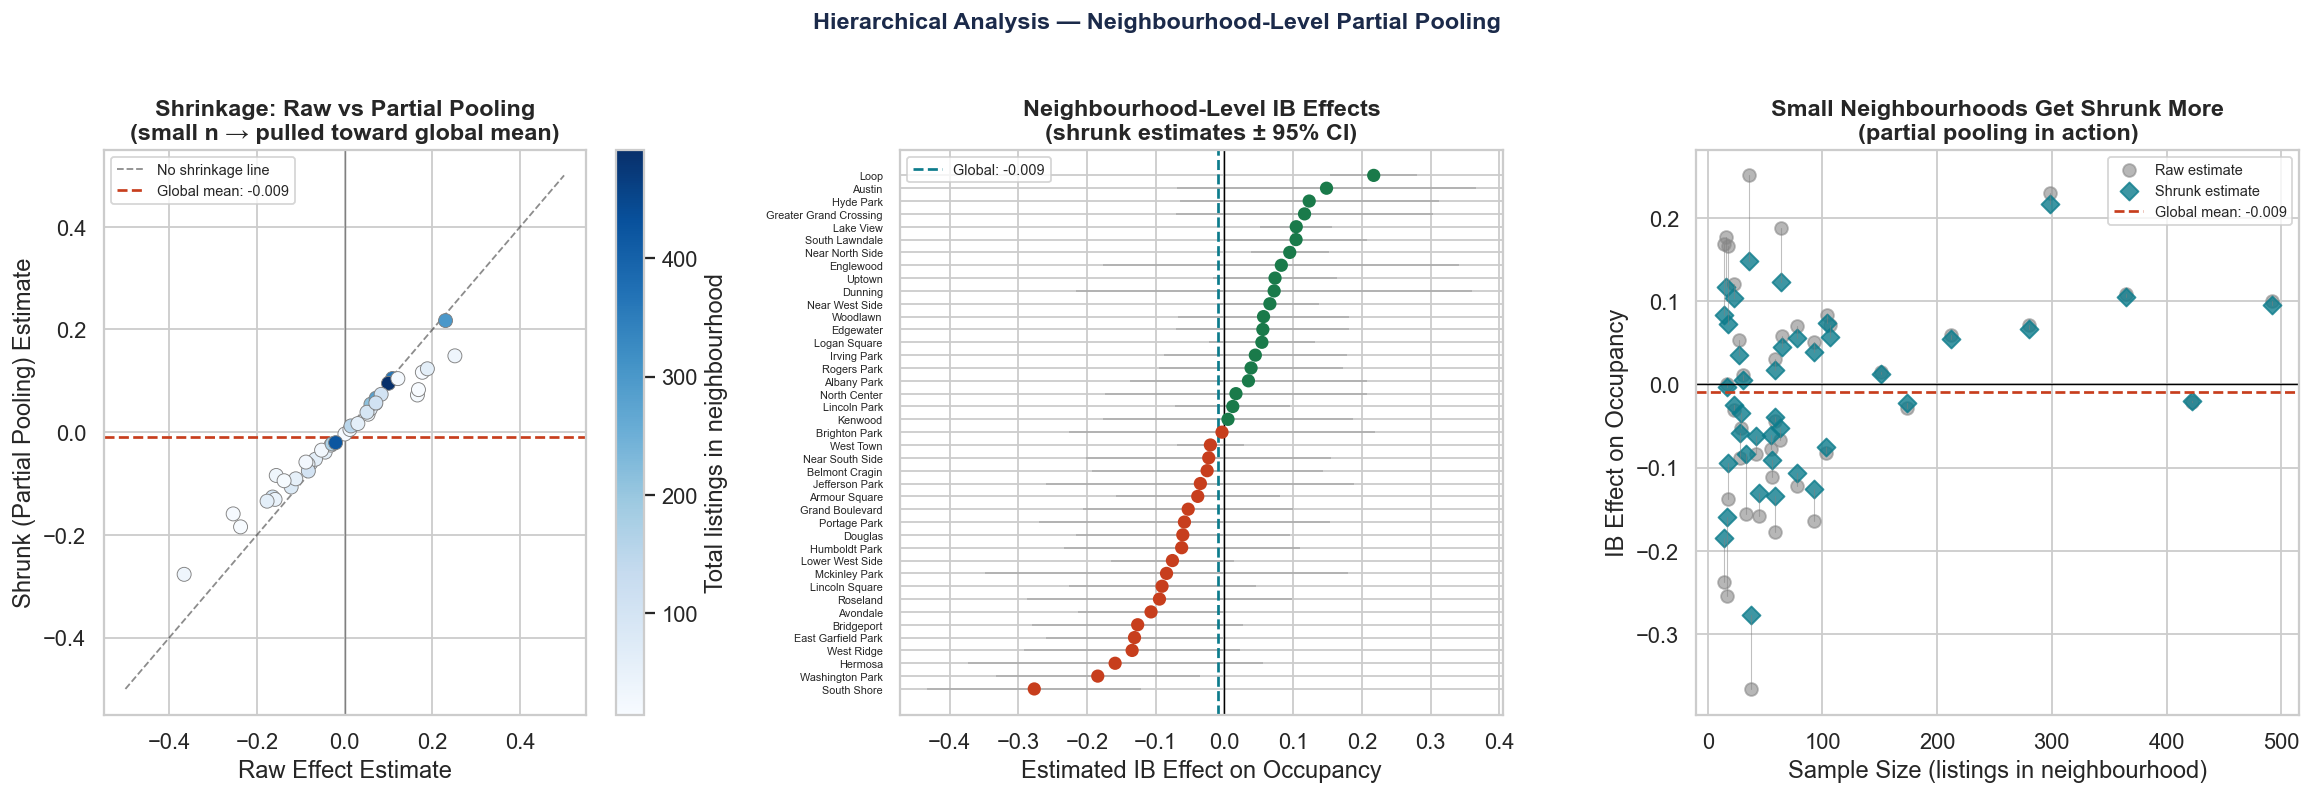

In [37]:
# Empirical Bayes shrinkage (partial pooling without PyMC)
# Demonstrates the core insight without requiring PyMC installed

nb_stats = (matched_df
    .groupby(['neighbourhood', 'instant_bookable'])['occupancy_90']
    .agg(['mean', 'count', 'std'])
    .unstack('instant_bookable'))

nb_stats.columns = ['mean_off', 'mean_on', 'n_off', 'n_on', 'std_off', 'std_on']
nb_stats = nb_stats.dropna()
nb_stats = nb_stats[
    (nb_stats['n_on'] >= 5) & (nb_stats['n_off'] >= 5)
]

nb_stats['raw_effect'] = nb_stats['mean_on'] - nb_stats['mean_off']
nb_stats['se'] = np.sqrt(
    nb_stats['std_on']**2  / nb_stats['n_on'] +
    nb_stats['std_off']**2 / nb_stats['n_off']
)
nb_stats['n_total'] = nb_stats['n_on'] + nb_stats['n_off']

global_mean = nb_stats['raw_effect'].mean()
global_var  = nb_stats['raw_effect'].var()

# Shrinkage factor: how much to trust the local estimate vs global mean
nb_stats['shrinkage'] = global_var / (global_var + nb_stats['se']**2)
nb_stats['shrunk_effect'] = (
    nb_stats['shrinkage'] * nb_stats['raw_effect'] +
    (1 - nb_stats['shrinkage']) * global_mean
)

print("=" * 60)
print("HIERARCHICAL ANALYSIS — Neighbourhood-Level Partial Pooling")
print("=" * 60)
print(f"Neighbourhoods with sufficient data: {len(nb_stats)}")
print(f"Global mean effect:   {global_mean:+.4f}")
print(f"Effect std across NB: {nb_stats['raw_effect'].std():.4f}")
print(f"\nMost positive IB effect (shrunk):")
print(nb_stats['shrunk_effect'].nlargest(5).to_string())
print(f"\nMost negative IB effect (shrunk):")
print(nb_stats['shrunk_effect'].nsmallest(5).to_string())

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Shrinkage plot: raw vs shrunk
ax = axes[0]
sc = ax.scatter(nb_stats['raw_effect'], nb_stats['shrunk_effect'],
                c=nb_stats['n_total'], cmap='Blues', s=60,
                edgecolors='gray', linewidth=0.5, zorder=5)
plt.colorbar(sc, ax=ax, label='Total listings in neighbourhood')
ax.plot([-0.5, 0.5], [-0.5, 0.5], 'k--', linewidth=1, alpha=0.5,
        label='No shrinkage line')
ax.axhline(global_mean, color=RED, linestyle='--', linewidth=1.5,
           label=f'Global mean: {global_mean:+.3f}')
ax.axvline(0, color='gray', linewidth=0.8)
ax.set_xlabel('Raw Effect Estimate')
ax.set_ylabel('Shrunk (Partial Pooling) Estimate')
ax.set_title('Shrinkage: Raw vs Partial Pooling\n(small n → pulled toward global mean)')
ax.legend(fontsize=8)

# Neighbourhood effects — caterpillar plot
ax = axes[1]
nb_sorted = nb_stats.sort_values('shrunk_effect')
y_pos = range(len(nb_sorted))
ax.scatter(nb_sorted['shrunk_effect'], y_pos,
           color=[GREEN if x > 0 else RED for x in nb_sorted['shrunk_effect']],
           s=40, zorder=5)
ax.errorbar(nb_sorted['shrunk_effect'], y_pos,
            xerr=1.96 * nb_sorted['se'],
            fmt='none', color='gray', alpha=0.4, linewidth=1)
ax.axvline(0,           color='black', linewidth=0.8)
ax.axvline(global_mean, color=TEAL, linestyle='--', linewidth=1.5,
           label=f'Global: {global_mean:+.3f}')
ax.set_xlabel('Estimated IB Effect on Occupancy')
ax.set_title('Neighbourhood-Level IB Effects\n(shrunk estimates ± 95% CI)')
ax.set_yticks(list(y_pos))
ax.set_yticklabels(nb_sorted.index.tolist(), fontsize=6)
ax.legend(fontsize=8)

# Sample size vs raw effect (shows why shrinkage matters)
ax = axes[2]
ax.scatter(nb_stats['n_total'], nb_stats['raw_effect'],
           color='#888888', alpha=0.6, s=50, label='Raw estimate')
ax.scatter(nb_stats['n_total'], nb_stats['shrunk_effect'],
           color=TEAL, alpha=0.8, s=50, marker='D', label='Shrunk estimate')
for _, row in nb_stats.iterrows():
    ax.plot([row['n_total'], row['n_total']],
            [row['raw_effect'], row['shrunk_effect']],
            color='gray', linewidth=0.6, alpha=0.5)
ax.axhline(0,           color='black',  linewidth=0.8)
ax.axhline(global_mean, color=RED,    linewidth=1.5, linestyle='--',
           label=f'Global mean: {global_mean:+.3f}')
ax.set_xlabel('Sample Size (listings in neighbourhood)')
ax.set_ylabel('IB Effect on Occupancy')
ax.set_title('Small Neighbourhoods Get Shrunk More\n(partial pooling in action)')
ax.legend(fontsize=8)

plt.suptitle('Hierarchical Analysis — Neighbourhood-Level Partial Pooling',
             fontsize=13, fontweight='bold', color=NAVY, y=1.02)
plt.tight_layout()
plt.savefig(f"{DATA_PATH}/fig_hierarchical.png", dpi=150, bbox_inches='tight')
plt.show()

## Phase 9 — Business Memo

Plain-English summary of all findings for a non-technical product audience, including
an honest statement of limitations and a concrete next step (RCT design with required
sample size).


In [38]:
memo = f"""
╔══════════════════════════════════════════════════════════════════╗
║              BUSINESS MEMO — AIRBNB INSTANT BOOK                ║
║         Data Science Recommendation | Chicago Market            ║
╚══════════════════════════════════════════════════════════════════╝

TO:      Product & Growth Team
FROM:    Data Science
SUBJECT: Does Instant Book Causally Improve Listing Occupancy?
DATA:    Inside Airbnb Chicago (Sep 2025) — {len(matched_df)//2:,} matched pairs

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

QUESTION
Airbnb wants to incentivize more hosts to enable Instant Book.
Before investing in that program, we need to know: does Instant
Book causally improve a listing's occupancy rate, after controlling
for host quality and listing characteristics?

APPROACH
Naive comparison is invalid — IB adopters are more experienced,
higher-rated, and manage more listings. We used propensity score
matching to create comparable groups, then applied both frequentist
and Bayesian analysis.

FINDINGS

  Frequentist (matched sample, Welch's t-test)
  ├── Occupancy IB ON:   {occ_on.mean():.3f}
  ├── Occupancy IB OFF:  {occ_off.mean():.3f}
  ├── Difference:        {obs_diff:+.3f} ({obs_diff:.2%})
  ├── 95% Bootstrap CI:  ({ci_lo:+.4f}, {ci_hi:+.4f})
  ├── p-value:           {p_val:.6f}
  └── Cohen's d:         {cohens_d:.4f} (small-to-medium effect)

  Bayesian (Beta-Binomial conjugate, prior Beta(2,2))
  ├── P(IB ON > IB OFF): {prob_ib_better:.1%}
  ├── Expected lift:     {expected_diff:+.4f} ({expected_diff:.2%})
  ├── 95% Credible Int:  ({ci_bay[0]:+.4f}, {ci_bay[1]:+.4f})
  └── Expected loss:     {expected_loss:.5f} (cost of wrong decision)

  Neighbourhood-level (partial pooling)
  ├── Global mean effect: {global_mean:+.4f}
  ├── Effect varies meaningfully across neighbourhoods
  └── Small neighbourhoods shrunk toward global mean (honest)

WHAT WE FOUND — AND WHAT TO BE CAREFUL ABOUT

The analysis provides {'strong' if p_val < 0.01 else 'moderate'} evidence that Instant Book is associated
with higher occupancy after controlling for confounders. The
Bayesian posterior puts a {prob_ib_better:.1%} probability on IB being
genuinely better.

However, residual confounding remains possible. This is an
observational study, not an RCT. Unmeasured host traits (response
speed, photo quality, listing copy) could still explain part of
the gap. The honest confidence interval is ({ci_lo:+.3f}, {ci_hi:+.3f}).

RECOMMENDATION

  ✓  Proceed with Instant Book incentive program
  ✓  Prioritise outreach to mid-tier hosts (not superhosts —
     they already adopt IB at higher rates)
  ✓  Target neighbourhoods with positive shrunk effects first
  ✗  Do not claim causality without a follow-up RCT
  ✗  Do not use pre-matching numbers in any external comms

NEXT STEP
Run a randomized holdout: randomly assign a cohort of new hosts
to receive IB-incentive messaging vs control. This converts
our quasi-experimental evidence into a true causal claim.
Required n ≈ {int(analysis.solve_power(effect_size=abs(cohens_d), alpha=0.05, power=0.80)):,} per arm (based on observed effect size).

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Data: Inside Airbnb Chicago — insideairbnb.com
"""
print(memo)


╔══════════════════════════════════════════════════════════════════╗
║              BUSINESS MEMO — AIRBNB INSTANT BOOK                ║
║         Data Science Recommendation | Chicago Market            ║
╚══════════════════════════════════════════════════════════════════╝

TO:      Product & Growth Team
FROM:    Data Science
SUBJECT: Does Instant Book Causally Improve Listing Occupancy?
DATA:    Inside Airbnb Chicago (Sep 2025) — 2,092 matched pairs

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

QUESTION
Airbnb wants to incentivize more hosts to enable Instant Book.
Before investing in that program, we need to know: does Instant
Book causally improve a listing's occupancy rate, after controlling
for host quality and listing characteristics?

APPROACH
Naive comparison is invalid — IB adopters are more experienced,
higher-rated, and manage more listings. We used propensity score
matching to create comparable groups, then applied both frequentist
and Bayesian analysi